In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import re
from scipy import optimize
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import pickle as pkl
from matplotlib.lines import Line2D
import collections
from collections import defaultdict
from sklearn.manifold import TSNE

def heatmap_auto_size(df, per_sample=0.4, per_row=0.3,
                      pad_lr=1.5, pad_tb=1.0,
                      min_w=6, max_w=40, min_h=3, max_h=30,
                      **hm_kwargs):
    n_samples = df.shape[1]
    n_rows = df.shape[0]
    # width scales with number of samples; height with number of rows
    width  = pad_lr + per_sample * n_samples
    height = pad_tb + per_row   * n_rows
    # clamp so it doesn't get absurdly small/large
    width  = max(min_w, min(max_w, width))
    height = max(min_h, min(max_h, height))
    return width, height

In [2]:
# --- imports ---
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import optimize

# --- inputs ---
### Load atlas ###
meth_atlas_tissues_fn = "/users/ludwig/cfo155/cfo155/tissueMap/methcalls/dmr_call_new1/all_sample.merged.mlml.mincov10_common.groupby.hg38_ws1000.s500.hmC.bgQ0.05-0.05.tgQ0.25.hyper_dmrs.bg_quant_modegroups.all.txt"
meth_atlas_tissues = pd.read_csv(meth_atlas_tissues_fn, sep="\t").set_index(['chr', 'start', 'end'])

# --- build per-tissue .mean columns (invert if mark is umC) ---
# Infer mark from filename (adjust if you want to force it)
if ".umC." in meth_atlas_tissues_fn:
    mark = "umC"
elif ".hmC." in meth_atlas_tissues_fn:
    mark = "hmC"
else:
    mark = "mC"

# DMR direction to keep later
sel_dmr = "Hypo" if mark == "mC" else "Hyper"

# Heuristic: first 116 columns hold replicate-level atlas signals → extract tissue names from suffix
rep_cols = meth_atlas_tissues.columns[:116]
all_tissue_types = sorted(set(re.sub(r'.*_', '', c) for c in rep_cols))

for tissue in all_tissue_types:
    # columns that END with _<tissue>
    cols = [c for c in rep_cols if c.endswith('_' + tissue)]
    if not cols:
        continue
    row_mean = meth_atlas_tissues[cols].mean(axis=1)
    if mark == "umC":
        row_mean = 1.0 - row_mean
    meth_atlas_tissues[f"{tissue}.mean"] = row_mean

sel_N = 200 # (out of 2000)
top_by_tissue = (
    meth_atlas_tissues
      .sort_values('delta_quants', ascending=False)
      .groupby('selected_tissue', group_keys=False)
      .head(sel_N)          # take top-N per group; ties are truncated arbitrarily
)

    

In [3]:
### Load cfCAPS cfDNA ###
samples_fn = "all_sample.merged.mlml.mincov10_common.groupby.hg38_ws1000.s500.hmC.bgQ0.05-0.05.tgQ0.25.hyper_dmrs.bg_quant_modegroups.all.txt.all_CpG.rC.CAPS.20snprm.txt"
samples_df = pd.read_csv(samples_fn, sep="\t").set_index(['chr', 'start', 'end'])
samples_df = samples_df.filter(like="rC").groupby(['chr', 'start', 'end'],dropna=True).mean()
# --- filter atlas rows/columns ---
exclude_tissues = [
    'Pancreas-Pancreatitis',
    'Ovary-Tumour','Kidney-Tumour','Brain-Tumour',
    'Prostate-Tumour','Breast-Tumour','Colon-Tumour','Stomach-Tumour','Lung-Tumour',
    # 'Pancreas-Tumour','Liver-Tumour','Liver-Cirrhosis'
]

df = top_by_tissue

# Expect these columns to exist in atlas:
#   'selected_tissue' & 'Hyper_or_Hypo'
row_mask = (~df['selected_tissue'].isin(exclude_tissues)) & (df['Hyper_or_Hypo'] == sel_dmr)

mean_cols = df.filter(like='.mean', axis=1).columns
bad_cols = {f"{t}.mean" for t in exclude_tissues}
keep_cols = [c for c in mean_cols if c not in bad_cols]

meth_atlas_tissues_filtered = df.loc[row_mask, keep_cols].copy()




In [5]:
re.sub(r'\.txt$',f'.selN{sel_N}.cfDNA_reference.txt', meth_atlas_tissues_fn)

'/users/ludwig/cfo155/cfo155/tissueMap/methcalls/dmr_call_new1/all_sample.merged.mlml.mincov10_common.groupby.hg38_ws1000.s500.hmC.bgQ0.05-0.05.tgQ0.25.hyper_dmrs.bg_quant_modegroups.all.selN200.cfDNA_reference.txt'

In [6]:
df.filter(like='.mean', axis=1).to_csv(re.sub(r'\.txt$',f'.selN{sel_N}.cfDNA_reference.txt', meth_atlas_tissues_fn), index=True, float_format='%.4f')

In [11]:
# ========== Deconvolution using rC inputs ==========
# Index join on (chr,start,end)
merged_rc = meth_atlas_tissues_filtered.join(samples_df, how='inner')
atlas_df = merged_rc.filter(like='.mean', axis=1)
samples_rc_df = merged_rc.filter(like='rC', axis=1)

# Convert once
A_full = atlas_df.to_numpy(dtype=float)                 # shape: bins x tissues
base_mask = np.isfinite(A_full).all(axis=1)             # rows with finite atlas

sample_mixtures = pd.DataFrame(index=atlas_df.columns)  # rows=tissues
residuals = []

for sample_name in samples_rc_df.columns:
    b_full = samples_rc_df[sample_name].to_numpy(dtype=float)

    # keep rows finite in both A and b
    mask = base_mask & np.isfinite(b_full)
    A = A_full[mask, :]
    b = b_full[mask]

    # optional: clip if you expect fractions
    # A = np.clip(A, 0, 1); b = np.clip(b, 0, 1)

    # need rows >= cols for a stable solve
    if A.shape[0] < A.shape[1]:
        print(f"Skip {sample_name}: not enough valid rows ({A.shape[0]}) "
              f"for {A.shape[1]} tissues.")
        continue

    w, res = optimize.nnls(A, b)
    s = w.sum()
    if s > 0:
        w = w / s
    sample_mixtures[sample_name] = w
    residuals.append(res)

# Tidy labels
sample_mixtures.index.name = 'atlas_tissues'
sample_mixtures.index = [re.sub(r'\.mean$', '', c) for c in sample_mixtures.index]
sample_mixtures.columns = [re.sub(r'\.rC$', '', c) for c in sample_mixtures.columns]

import re
def natsort_key(s):
    return [int(t) if t.isdigit() else t.lower() for t in re.split(r'(\d+)', s)]

sample_mixtures = sample_mixtures.loc[:, sorted(sample_mixtures.columns, key=natsort_key)]
tissue_order_all = ["CD34-megakaryocytes","Neutrophils", "Monocytes","CD34-erythroblasts","CD4-T-cells", "CD8-T-cells", "NK-cells", "B-cells",  "Eosinophils",
                    "Brain", "Breast", "Heart", "Kidney", "Liver", "Lung", "Ovary", "Pancreas", "Prostate", "Colon", "Stomach", "Esophagus", "Spleen", 
                    "Liver-Cirrhosis", "Pancreas-Pancreatitis",
                    "Brain-Tumour", "Breast-Tumour", "Colon-Tumour", "Kidney-Tumour", "Liver-Tumour", "Pancreas-Tumour","Lung-Tumour",  "Ovary-Tumour",  "Prostate-Tumour","Stomach-Tumour"
                ]
exclude_set = set(exclude_tissues)  
tissue_order = [t for t in tissue_order_all if t not in exclude_set]
sample_mixtures = sample_mixtures.reindex(tissue_order).dropna(how="all")

sample_mixtures.to_csv(re.sub(r'\.txt$',f'.selN{sel_N}.tissue_contribution.txt', samples_fn), index=True, index_label='tissue', float_format='%.4f')
# Heatmap
width, height=heatmap_auto_size(sample_mixtures)
plt.figure(figsize=(width, height))
sns.heatmap(sample_mixtures, cmap='RdBu_r', annot=True, fmt='.2f', linewidths=0.5, annot_kws={"fontsize":8})
plt.title(f'Tissue contribution(top {sel_N} hyper hmC)', fontsize=16)
plt.xlabel("Samples", fontsize=12)
plt.ylabel("Tissues", fontsize=12)
plt.tight_layout()
plt.savefig(re.sub(r'\.txt$', f'.selN{sel_N}.tissue_contribution.pdf', samples_fn), format='pdf')
plt.savefig(re.sub(r'\.txt$', f'.selN{sel_N}.tissue_contribution.png', samples_fn), format='png', dpi=300)
plt.close()


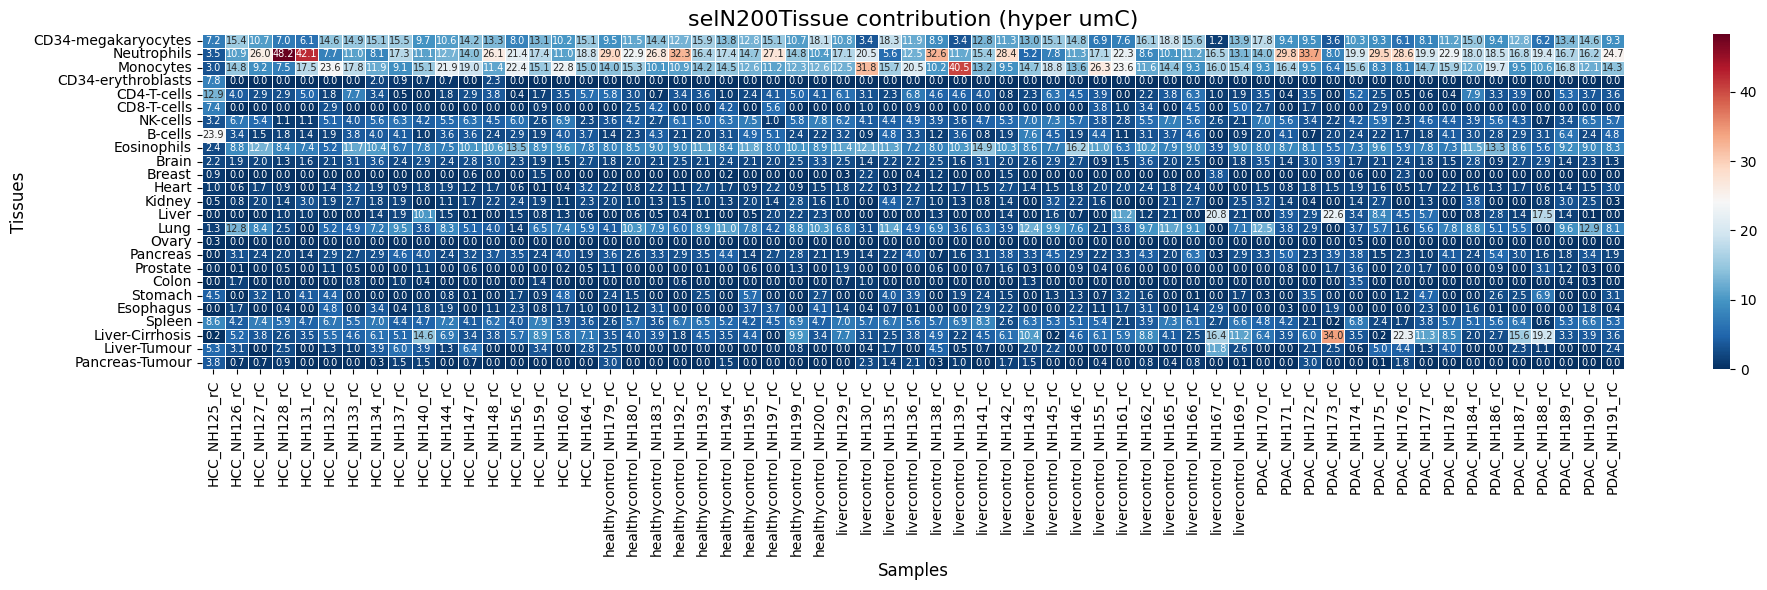

In [12]:
fig, ax = plt.subplots(figsize=(20, 6))

# sns.heatmap(sample_mixtures, cmap='RdBu_r', linewidths=0.5,
#             annot_kws={"fontsize": 8}, ax=ax)
sns.heatmap(sample_mixtures*100, cmap='RdBu_r', annot=True, fmt='.1f', linewidths=0.5, annot_kws={"fontsize":7})
plt.title(f'selN{sel_N}Tissue contribution (hyper umC)', fontsize=16)
plt.xlabel("Samples", fontsize=12)
plt.ylabel("Tissues", fontsize=12)

# ---- SHOW ALL ROW NAMES ----
ax.set_yticks(np.arange(len(sample_mixtures.index)) + 0.5)
ax.set_yticklabels(sample_mixtures.index, rotation=0)

# ---- SHOW ALL COLUMN NAMES ----
ax.set_xticks(np.arange(len(sample_mixtures.columns)) + 0.5)
ax.set_xticklabels(sample_mixtures.columns, rotation=90)

plt.tight_layout()
plt.show()

Group counts:
 Group
Cirrhosis    18
HCC          17
Healthy      10
Name: count, dtype: int64

=== T-test Results ===
Healthy vs Cirrhosis: TtestResult(statistic=np.float64(-1.1607906911869565), pvalue=np.float64(0.26023453186507023), df=np.float64(18.82705029694495))
Healthy vs HCC: TtestResult(statistic=np.float64(-0.5651957975482511), pvalue=np.float64(0.5774819701472298), df=np.float64(22.71054325124969))
Cirrhosis vs HCC: TtestResult(statistic=np.float64(0.8181343718356451), pvalue=np.float64(0.4213898052300561), df=np.float64(23.819755667095418))

=== Mann-Whitney U (Wilcoxon rank-sum) Results ===
Healthy vs Cirrhosis: MannwhitneyuResult(statistic=np.float64(100.0), pvalue=np.float64(0.6384591961050708))
Healthy vs HCC: MannwhitneyuResult(statistic=np.float64(90.0), pvalue=np.float64(0.8189489457258702))
Cirrhosis vs HCC: MannwhitneyuResult(statistic=np.float64(152.0), pvalue=np.float64(0.9862847573633746))


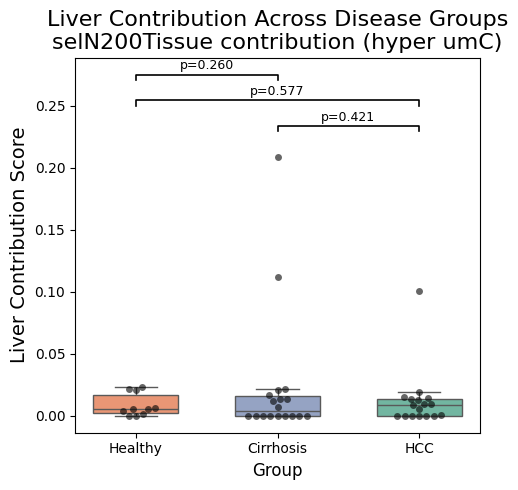

In [17]:
### Load cfTAPS cfDNA (this include deliver patients)###
from scipy.stats import ttest_ind, mannwhitneyu

# ------------- Config ----------------
sel_tissue_type = "Liver"   # must match a row in sample_mixtures.index
# --------------------------------------

# 1) Load your mixture matrix
df = sample_mixtures.copy()

# 2) Extract contributions for the selected tissue row
vals = df.loc[sel_tissue_type]     # Series: index=sample names

# 3) Classify sample groups based on column names
def classify_sample(colname):
    if re.search("livercontrol", colname, re.IGNORECASE):
        return "Cirrhosis"
    elif re.search(r"\bHCC\b|HCC_", colname, re.IGNORECASE):
        return "HCC"
    elif re.search("healthycontrol", colname, re.IGNORECASE):
        return "Healthy"
    else:
        return "Other"

groups = vals.index.to_series().apply(classify_sample)

# Keep only the three groups of interest
mask = groups.isin(["Healthy", "Cirrhosis", "HCC"])
vals = vals[mask]
groups = groups[mask]

# 4) Build tidy DataFrame (column name = sel_tissue_type)
data = pd.DataFrame({
    sel_tissue_type: vals.values,
    "Group": groups.values
})

print("Group counts:\n", data["Group"].value_counts())

# 5) Extract values for t-tests
healthy = data.loc[data["Group"] == "Healthy", sel_tissue_type]
cirrhosis = data.loc[data["Group"] == "Cirrhosis", sel_tissue_type]
hcc = data.loc[data["Group"] == "HCC", sel_tissue_type]

def safe_ttest(a, b):
    if len(a) < 2 or len(b) < 2:
        return None
    return ttest_ind(a, b, equal_var=False)

def safe_mannwhitney(a, b):
    try:
        if len(a) < 1 or len(b) < 1:
            return None
        # two-sided Mann-Whitney U (Wilcoxon rank-sum)
        return mannwhitneyu(a, b, alternative="two-sided")
    except Exception:
        return None
ttest_H_vs_C = safe_ttest(healthy, cirrhosis)
ttest_H_vs_HCC = safe_ttest(healthy, hcc)
ttest_C_vs_HCC = safe_ttest(cirrhosis, hcc)

print("\n=== T-test Results ===")
print("Healthy vs Cirrhosis:", ttest_H_vs_C)
print("Healthy vs HCC:", ttest_H_vs_HCC)
print("Cirrhosis vs HCC:", ttest_C_vs_HCC)

mw_H_vs_C = safe_mannwhitney(healthy, cirrhosis)
mw_H_vs_HCC = safe_mannwhitney(healthy, hcc)
mw_C_vs_HCC = safe_mannwhitney(cirrhosis, hcc)


print("\n=== Mann-Whitney U (Wilcoxon rank-sum) Results ===")
print("Healthy vs Cirrhosis:", mw_H_vs_C)
print("Healthy vs HCC:", mw_H_vs_HCC)
print("Cirrhosis vs HCC:", mw_C_vs_HCC)
# ---------------------------
# 6) Plot with correct ordering
# ---------------------------

# If you prefer a fixed order, uncomment and set explicitly:
order = ["Healthy", "Cirrhosis", "HCC"]

fig, ax = plt.subplots(figsize=(5,5))

sns.boxplot(
    data=data,
    x="Group",
    y=sel_tissue_type,
    hue="Group",
    palette="Set2",
    dodge=False,
    order=order,
    ax=ax,
    showfliers=False,
    width=0.6
)
# remove legend produced by hue
if ax.get_legend() is not None:
    ax.get_legend().remove()

sns.swarmplot(
    data=data,
    x="Group",
    y=sel_tissue_type,
    order=order,
    color="k",
    alpha=0.6,
    ax=ax
)

plt.title(f"{sel_tissue_type} Contribution Across Disease Groups\nselN{sel_N}Tissue contribution (hyper umC)", fontsize=16)
plt.ylabel(f"{sel_tissue_type} Contribution Score", fontsize=14)
plt.xlabel("Group", fontsize=12)

# 7) Significance annotations using the same order
ymax = data[sel_tissue_type].max()
ymin = data[sel_tissue_type].min()
yrange = max(ymax - ymin, 1e-6)
gap = yrange * 0.1

# x positions according to 'order'
x_positions = {name: i for i, name in enumerate(order)}

def add_pval_annotation(x1_name, x2_name, pval, y_base):
    if x1_name not in x_positions or x2_name not in x_positions:
        return
    x1 = x_positions[x1_name]
    x2 = x_positions[x2_name]
    if pval is None:
        label = "n<2"
    else:
        label = f"p={pval:.3e}" if pval < 0.001 else f"p={pval:.3f}"
    h = yrange * 0.02
    ax.plot([x1, x1, x2, x2], [y_base, y_base+h, y_base+h, y_base], lw=1.2, color='black')
    ax.text((x1 + x2) / 2, y_base + h + (yrange * 0.01), label, ha='center', va='bottom', fontsize=9)

# stack annotation heights so they don't overlap
base_levels = [ymax + gap * i for i in range(1, 4)]

# Draw comparisons (use group NAMES so mapping is explicit)
add_pval_annotation("Cirrhosis", "HCC", ttest_C_vs_HCC.pvalue if ttest_C_vs_HCC else None, base_levels[0])
add_pval_annotation("Healthy", "HCC", ttest_H_vs_HCC.pvalue if ttest_H_vs_HCC else None, base_levels[1])
add_pval_annotation("Healthy", "Cirrhosis", ttest_H_vs_C.pvalue if ttest_H_vs_C else None, base_levels[2])

plt.tight_layout()
plt.show()
